# 1. Batch Overview

## 1a) Batch 1 and 2

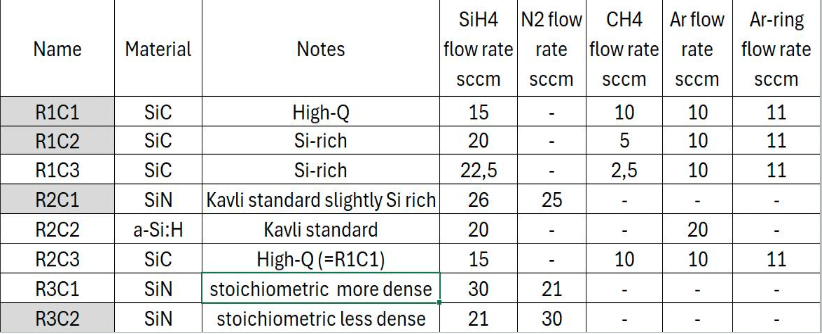

In [1]:
from IPython.display import Image, display
display(Image("Table_Batch_1_and_2.png"))

#### R1C1 - Delaminated 
#### R1C2 - Delaminated
#### R1C3 - $tan(\delta) \approx 1.66E-04$
#### R2C1 - $tan(\delta) \approx 9.1E-04$
#### R2C2 - Cracked during fab
#### R2C3 - $tan(\delta) \approx 1.54E-04$, best from batch
#### R3C1 - $tan(\delta) \approx 4.65E-04$
#### R3C2 - $tan(\delta) \approx 3.5E-03$

## 1b) Batch 3

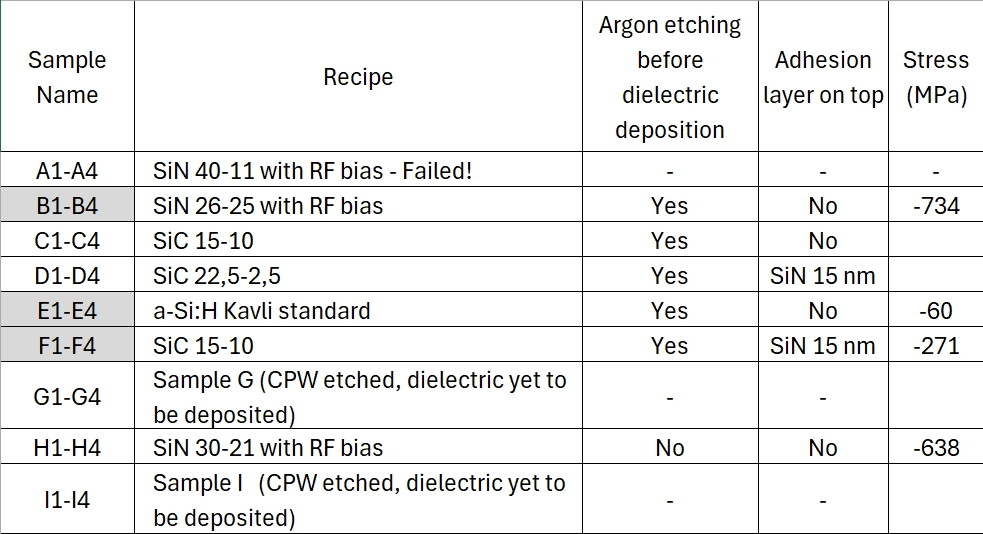

In [2]:
from IPython.display import Image, display
display(Image("Table_Batch_3.png"))

### B1 - $tan(\delta) \approx 3.68E-04$
### B2 - $tan(\delta) \approx 3.67E-04$
### B3 - not testing
### B4 - not testing


### E1 - $tan(\delta) \approx 6.038E-05$
### E2 - 
### E3 - not testing
### E4 - not testing


### F1 - $tan(\delta) \approx 6.2E-05$
### F2 - 
### F3 - $tan(\delta) \approx 7.9E-05$
### F4 - $tan(\delta) = 8.0856e-05$

____

# 2. Analysis of our data

### 2a) Dataframe and plot of all of our data.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np

# R2C1, PECVD, SiN
R2C1 = pd.DataFrame(
    {
        "freq": [5.42,5.75,6.13,6.56],
        "Fd": [9.01e-4,9.12e-4,9.2e-4,9.22e-4], #TLS-only, combined mag up and down
        "N/S ratio": [25./26., 25./26., 25./26., 25./26.],
    }
)

# R3C2, ICPCVD, Less Dense SiN
R3C2 = pd.DataFrame(
    {
        "freq": [5.56, 6.305, 6.755],
        "Fd": [33.13e-4, 32.68e-4, 33.32e-4], #TLS-only, combined mag up and down
        "N/S ratio": [30./21., 30./21., 30./21.],
    }

)

# R3C1, ICPCVD, More Dense SiN
R3C1 = pd.DataFrame(
    {
        "freq": [5.19, 5.50, 5.87, 6.28],
        "Fd": [4.60e-4, 4.64E-04, 4.72E-04, 4.74E-04], #TLS-only, combined mag up and down
        "N/S ratio":  [21./30., 21./30., 21./30., 21./30.]
    }

)

# R1C3, ICPCVD, Si-rich SiC
R1C3 = pd.DataFrame(
    {
        "freq": [4.66, 4.94, 5.2790],
        "Fd": [1.80e-4, 1.79e-4, 1.80e-4], #TLS-only, combined all mag cycles
        "Fd_mag_up_fast": [1.75e-4, 1.80E-04, 1.78E-04],
        "Fd_mag_down_fast": [1.49e-4, 1.53E-04, 1.55E-04],
        "Fd_mag_up_slow": [1.71e-4, 1.75E-04, 1.75E-04],
        "Fd_mag_down_slow": [1.61e-4, 1.66E-04, 1.65E-04],
        "C/S ratio": [2.5/22.5, 2.5/22.5, 2.5/22.5]
    }
)

# R2C3, ICPCVD, High-Q Twin SiC
R2C3 = pd.DataFrame(
    {
        "freq": [5.83],
        "Fd": [1.54e-4], #TLS-only, combined mag up and mag down
        "C/S ratio": [10./15.]
    }
)

#F1, ICPCVD, SiC
F1 = pd.DataFrame(
    {
        "freq": [5.00, 5.31, 5.66, 6.06],
        "Fd": [0.70e-4, 0.64e-4, 0.57e-4, 0.57e-4], #TLS-only, combined mag up and down
        "C/S ratio": [10./15., 10./15., 10./15., 10./15.]
    }
)

#F4, ICPCVD, SiC, lambda/4
F4 = pd.DataFrame(
    {
        "freq": [5.2147], #had another one but fit was bad
        "Fd": [8.0856e-05], #TLS-only, combined mag up and down
        "C/S ratio": [10./15.]
    }
)

#E1, ICPCVD, a-Si:H, lambda/2
E1 = pd.DataFrame(
    {
        "freq": [4.2696, 5.0048, 5.6559], #fourth one likely swallowed by box modes, 5.00 GHz -60db cut
        "Fd": [6.4369e-5, 5.9822e-05, 5.6938e-05], #TLS-only, combined mag up and down
        "C/S ratio": [0./1., 0./1., 0./1.]
    }
)

#B1, ICPCVD, SiNx w/ RF bias, lambda/2
B1 = pd.DataFrame(
    {
        "freq": [5.4504, 5.7958], #rez2 and rez3 had poor fits
        "Fd": [3.6796e-04, 3.6965e-04], #TLS-only, combined mag up and down
        "N/S ratio": [25./26., 25./26.]
    }
)

#B2, ICPCVD, SiNx w/ RF bias, lambda/2 - 1st point from R1C3 + B2 run, 2nd from B2 + F3 run
B2 = pd.DataFrame(
    {
        "freq": [5.4597, 5.46],
        "Fd": [3.6187e-04, 3.73e-04], #TLS-only, combined mag up and down
        "N/S ratio": [25./26., 25./26.]
    }
)

#F3, ICPCVD, SiC, lambda/4 - data from B2 + F3 run
F3 = pd.DataFrame(
    {
        "freq": [4.99, 5.28, 5.65], 
        "Fd": [0.74e-04, 0.91e-04, 0.72e-04], #TLS-only, combined mag up and down
        "C/S ratio": [10./15., 10./15., 10./15.]
    }
)

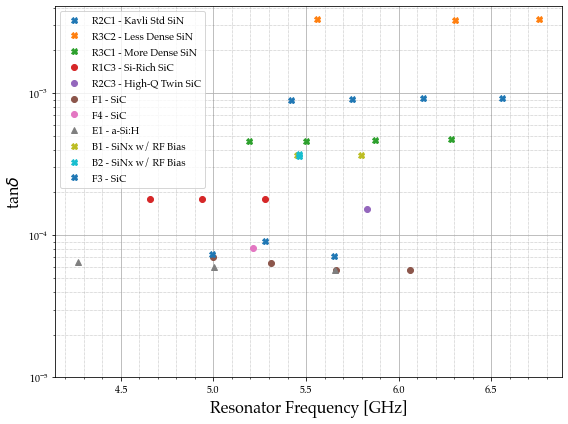

In [150]:
plt.figure(figsize=(8,6))

plt.plot(R2C1['freq'].iloc[0:4], R2C1['Fd'].iloc[0:4], 'X', label='R2C1 - Kavli Std SiN')
plt.plot(R3C2['freq'].iloc[0:4], R3C2['Fd'].iloc[0:4], 'X', label='R3C2 - Less Dense SiN')
plt.plot(R3C1['freq'].iloc[0:4], R3C1['Fd'].iloc[0:4], 'X', label='R3C1 - More Dense SiN')
plt.plot(R1C3['freq'].iloc[0:4], R1C3['Fd'].iloc[0:4], 'o', label='R1C3 - Si-Rich SiC')
plt.plot(R2C3['freq'].iloc[0:4], R2C3['Fd'].iloc[0:4], 'o', label='R2C3 - High-Q Twin SiC')
plt.plot(F1['freq'].iloc[0:4], F1['Fd'].iloc[0:4], 'o', label='F1 - SiC')
plt.plot(F4['freq'].iloc[0:4], F4['Fd'].iloc[0:4], 'o', label='F4 - SiC')
plt.plot(E1['freq'].iloc[0:4], E1['Fd'].iloc[0:4], '^', label='E1 - a-Si:H')
plt.plot(B1['freq'].iloc[0:4], B1['Fd'].iloc[0:4], 'X', label='B1 - SiNx w/ RF Bias')
plt.plot(B2['freq'].iloc[0:4], B2['Fd'].iloc[0:4], 'X', label='B2 - SiNx w/ RF Bias')
plt.plot(F3['freq'].iloc[0:4], F3['Fd'].iloc[0:4], 'X', label='F3 - SiC')



plt.yscale('log')
plt.ylabel("tan$\delta$", fontsize=16)
plt.xlabel("Resonator Frequency [GHz]", fontsize=16)
plt.ylim(bottom=1e-5)
plt.legend()
plt.grid(True)
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', linewidth='0.5', color='gray')
plt.tight_layout()
plt.savefig('plots/loss_sample_comparison_LANCE_only.png')
plt.show()

### 2b) Comparing frequency schedule

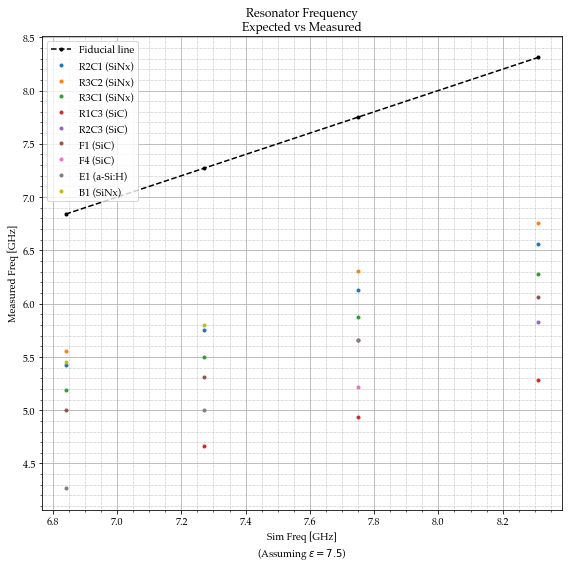

In [151]:
# Compare freq sched
fiducial = np.array([6.84,7.27,7.75,8.31])

plt.figure(2,figsize=(8,8))
plt.plot(fiducial,fiducial,'k.--',label='Fiducial line')
plt.plot(fiducial,R2C1['freq'].iloc[0:4],'.',label='R2C1 (SiNx)')
plt.plot([fiducial[0], fiducial[2], fiducial[3]],R3C2['freq'].iloc[0:4],'.',label='R3C2 (SiNx)')
plt.plot(fiducial,R3C1['freq'].iloc[0:4],'.',label='R3C1 (SiNx)')
plt.plot([fiducial[1], fiducial[2], fiducial[3]], R1C3['freq'].iloc[0:4],'.',label='R1C3 (SiC)')
plt.plot([fiducial[3]], R2C3['freq'].iloc[0:4],'.',label='R2C3 (SiC)')
plt.plot(fiducial, F1['freq'].iloc[0:4],'.',label='F1 (SiC)')
plt.plot([fiducial[2]], F4['freq'].iloc[0:4],'.',label='F4 (SiC)')
plt.plot([fiducial[0], fiducial[1], fiducial[2]], E1['freq'].iloc[0:4],'.',label='E1 (a-Si:H)')
plt.plot([fiducial[0], fiducial[1]], B1['freq'].iloc[0:4],'.',label='B1 (SiNx)')


plt.ylabel('Measured Freq [GHz]')
plt.xlabel('Sim Freq [GHz]\n(Assuming $\epsilon=7.5$)')
plt.legend(loc='upper left')
plt.grid(True)
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', linewidth='0.5', color='gray')
plt.title('Resonator Frequency\nExpected vs Measured')
plt.tight_layout()
plt.savefig('plots/freq_compare.png',dpi=300)

### 2c) Silicon fraction visualization

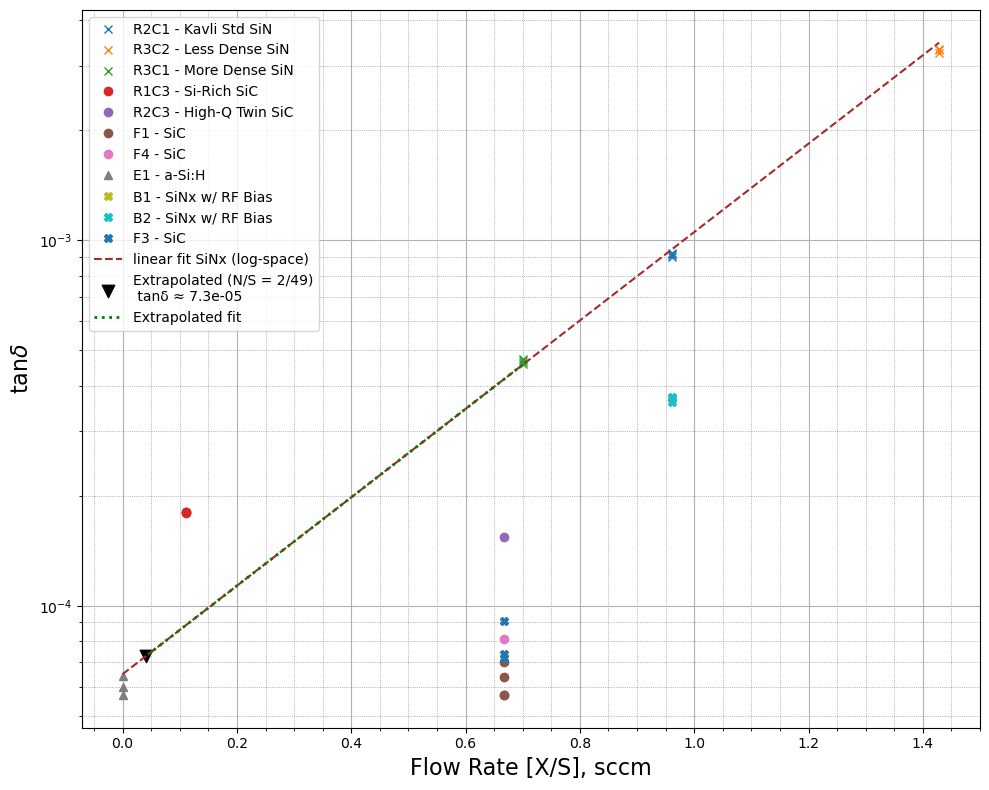

Log-space slope: 2.786
Log-space intercept: -9.642


In [2]:
import numpy as np
from scipy.optimize import curve_fit

plt.figure(figsize=(10,8))
plt.plot(R2C1['N/S ratio'].iloc[0:4], R2C1['Fd'].iloc[0:4], 'x', label='R2C1 - Kavli Std SiN')
plt.plot(R3C2['N/S ratio'].iloc[0:4], R3C2['Fd'].iloc[0:4], 'x', label='R3C2 - Less Dense SiN')
plt.plot(R3C1['N/S ratio'].iloc[0:4], R3C1['Fd'].iloc[0:4], 'x', label='R3C1 - More Dense SiN')
plt.plot(R1C3['C/S ratio'].iloc[0:4], R1C3['Fd'].iloc[0:4], 'o', label='R1C3 - Si-Rich SiC')
plt.plot(R2C3['C/S ratio'].iloc[0:4], R2C3['Fd'].iloc[0:4], 'o', label='R2C3 - High-Q Twin SiC')
plt.plot(F1['C/S ratio'].iloc[0:4], F1['Fd'].iloc[0:4], 'o', label='F1 - SiC')
plt.plot(F4['C/S ratio'].iloc[0:4], F4['Fd'].iloc[0:4], 'o', label='F4 - SiC')
plt.plot(E1['C/S ratio'].iloc[0:4], E1['Fd'].iloc[0:4], '^', label='E1 - a-Si:H')
plt.plot(B1['N/S ratio'].iloc[0:4], B1['Fd'].iloc[0:4], 'X', label='B1 - SiNx w/ RF Bias')
plt.plot(B2['N/S ratio'].iloc[0:4], B2['Fd'].iloc[0:4], 'X', label='B2 - SiNx w/ RF Bias')
plt.plot(F3['C/S ratio'].iloc[0:4], F3['Fd'].iloc[0:4], 'X', label='F3 - SiC')

def log_lin_fit(x, m, c):
    return np.exp(m*x + c)

x_data = np.array([25./26., 25./26., 25./26., 25./26., 30./21., 30./21., 30./21., 21./30., 21./30., 21./30., 21./30.])
y_data = np.array([9.01e-4,9.12e-4,9.2e-4,9.22e-4, 3.49e-3, 3.49e-3, 3.64e-3, 4.60e-4, 4.64E-04, 4.72E-04, 4.74E-04])

popt, pcov = curve_fit(lambda x, m, c: m*x + c, x_data, np.log(y_data))
m_log, c_log = popt

x_fit = np.linspace(0, max(x_data), 200) #np.linspace(min(x_data), max(x_data), 200)
y_fit = np.exp(m_log * x_fit + c_log)


plt.plot(x_fit, y_fit, '--', color='brown', label='linear fit SiNx (log-space)')


# Extrapolate to N/S = 2/49, Hail-Mary SiNx
x_extrap = 2/49
y_extrap = np.exp(m_log * x_extrap + c_log)
plt.scatter(x_extrap, y_extrap, color='black', marker='v', s=80,
            label=f'Extrapolated (N/S = 2/49)\n tanδ ≈ {y_extrap:.1e}')

x_fit_data = np.linspace(min(x_data), max(x_data), 200)
x_fit_extrap = np.linspace(min(x_fit_data), x_extrap, 100)
y_fit_data = np.exp(m_log * x_fit_data + c_log)
y_fit_extrap = np.exp(m_log * x_fit_extrap + c_log)
plt.plot(x_fit_extrap, y_fit_extrap, ':', color='green', linewidth=2, label='Extrapolated fit')


plt.yscale('log')
plt.ylabel("tan$\delta$", fontsize=16)
plt.xlabel("Flow Rate [X/S], sccm", fontsize=16)
plt.legend(loc='upper left')
plt.grid(True)
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', linewidth='0.5', color='gray')
plt.tight_layout()
#plt.savefig('plots/Silicon_Frac_Visualization.png',dpi=300)
plt.show()

print(f"Log-space slope: {m_log:.3f}")
print(f"Log-space intercept: {c_log:.3f}")

### 2c.2) Silicon fraction visualization (simplified)

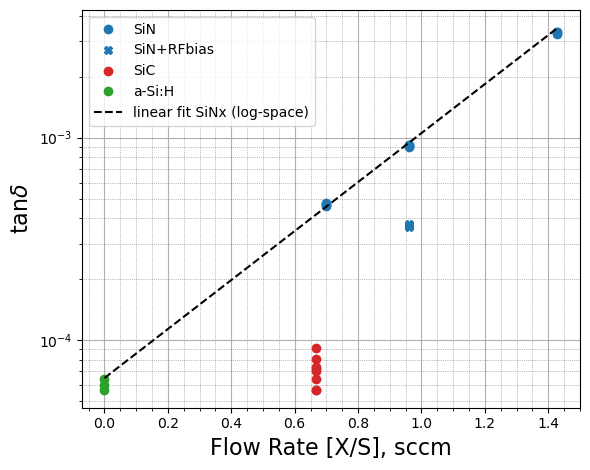

Log-space slope: 2.786
Log-space intercept: -9.642


In [18]:
import numpy as np
from scipy.optimize import curve_fit

plt.close('all')
#plt.figure(figsize=(10,8))
plt.figure("SiFracSimple",figsize=(6,6*0.8))
sinlab, = plt.plot([],[],'o',color="tab:blue",label='SiN')
sinrflab, = plt.plot([],[],'X',color="tab:blue",label='SiN+ RF Bias')
siclab, = plt.plot([],[],'o',color="tab:red",label='SiC')
asilab, = plt.plot([],[],'o',color="tab:green",label='a-Si:H')

plt.plot(R2C1['N/S ratio'].iloc[0:4], R2C1['Fd'].iloc[0:4], 'o',color="tab:blue", label='R2C1 - Kavli Std SiN')
plt.plot(R3C2['N/S ratio'].iloc[0:4], R3C2['Fd'].iloc[0:4], 'o',color="tab:blue", label='R3C2 - Less Dense SiN')
plt.plot(R3C1['N/S ratio'].iloc[0:4], R3C1['Fd'].iloc[0:4], 'o',color="tab:blue", label='R3C1 - More Dense SiN')
#plt.plot(R1C3['C/S ratio'].iloc[0:4], R1C3['Fd'].iloc[0:4], 'o', label='R1C3 - Si-Rich SiC')
#plt.plot(R2C3['C/S ratio'].iloc[0:4], R2C3['Fd'].iloc[0:4], 'o', label='R2C3 - High-Q Twin SiC')
plt.plot(F1['C/S ratio'].iloc[0:4], F1['Fd'].iloc[0:4], 'o',color="tab:red", label='F1 - SiC')
plt.plot(F4['C/S ratio'].iloc[0:4], F4['Fd'].iloc[0:4], 'o',color="tab:red", label='F4 - SiC')
plt.plot(E1['C/S ratio'].iloc[0:4], E1['Fd'].iloc[0:4], 'o',color="tab:green", label='E1 - a-Si:H')
plt.plot(B1['N/S ratio'].iloc[0:4], B1['Fd'].iloc[0:4], 'X',color="tab:blue", label='B1 - SiNx w/ RF Bias')
plt.plot(B2['N/S ratio'].iloc[0:4], B2['Fd'].iloc[0:4], 'X',color="tab:blue", label='B2 - SiNx w/ RF Bias')
plt.plot(F3['C/S ratio'].iloc[0:4], F3['Fd'].iloc[0:4], 'o',color="tab:red", label='F3 - SiC')

def log_lin_fit(x, m, c):
    return np.exp(m*x + c)

x_data = np.array([25./26., 25./26., 25./26., 25./26., 30./21., 30./21., 30./21., 21./30., 21./30., 21./30., 21./30.])
y_data = np.array([9.01e-4,9.12e-4,9.2e-4,9.22e-4, 3.49e-3, 3.49e-3, 3.64e-3, 4.60e-4, 4.64E-04, 4.72E-04, 4.74E-04])

popt, pcov = curve_fit(lambda x, m, c: m*x + c, x_data, np.log(y_data))
m_log, c_log = popt

x_fit = np.linspace(0, max(x_data), 200) #np.linspace(min(x_data), max(x_data), 200)
y_fit = np.exp(m_log * x_fit + c_log)


linfitlab, = plt.plot(x_fit, y_fit, '--', color='k', label='linear fit SiNx (log-space)')


# Extrapolate to N/S = 2/49, Hail-Mary SiNx
x_extrap = 2/49
y_extrap = np.exp(m_log * x_extrap + c_log)
# plt.scatter(x_extrap, y_extrap, color='black', marker='v', s=80,
#             label=f'Extrapolated (N/S = 2/49)\n tanδ ≈ {y_extrap:.1e}')

x_fit_data = np.linspace(min(x_data), max(x_data), 200)
x_fit_extrap = np.linspace(min(x_fit_data), x_extrap, 100)
y_fit_data = np.exp(m_log * x_fit_data + c_log)
y_fit_extrap = np.exp(m_log * x_fit_extrap + c_log)
# plt.plot(x_fit_extrap, y_fit_extrap, ':', color='green', linewidth=2, label='Extrapolated fit')


plt.yscale('log')
plt.ylabel("tan$\delta$", fontsize=16)
plt.xlabel("Flow Rate [X/S], sccm", fontsize=16)
plt.legend([sinlab,sinrflab,siclab,asilab,linfitlab],["SiN","SiN+RFbias","SiC","a-Si:H","linear fit SiNx (log-space)"],loc='upper left')
plt.grid(True)
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', linewidth='0.5', color='gray')
plt.tight_layout()
plt.savefig('plots/Silicon_Frac_Visualization_Simple.png',dpi=300)
plt.show()

print(f"Log-space slope: {m_log:.3f}")
print(f"Log-space intercept: {c_log:.3f}")

### 2d) Thermalization test

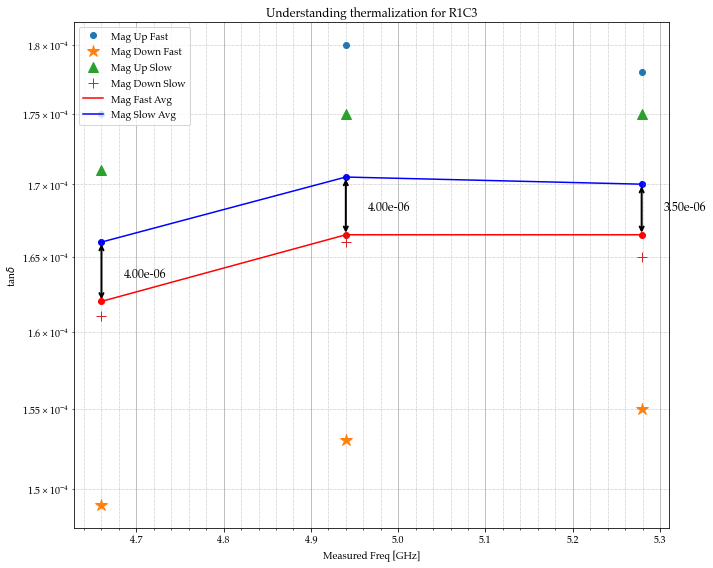

In [154]:
#Understanding thermalization with R1C3

plt.figure(figsize=(10, 8))
plt.plot(R1C3['freq'].iloc[0:4], R1C3['Fd_mag_up_fast'].iloc[0:4], '.', markersize=12, label='Mag Up Fast')
plt.plot(R1C3['freq'].iloc[0:4], R1C3['Fd_mag_down_fast'].iloc[0:4], '*', markersize=12, label='Mag Down Fast')
plt.plot(R1C3['freq'].iloc[0:4], R1C3['Fd_mag_up_slow'].iloc[0:4], '^', markersize=10, label='Mag Up Slow')
plt.plot(R1C3['freq'].iloc[0:4], R1C3['Fd_mag_down_slow'].iloc[0:4], '+', markersize=10, label='Mag Down Slow')

mag_fast_avg = np.array([np.average([R1C3['Fd_mag_up_fast'].iloc[0], R1C3['Fd_mag_down_fast'].iloc[0]]), \
                        np.average([R1C3['Fd_mag_up_fast'].iloc[1], R1C3['Fd_mag_down_fast'].iloc[1]]), \
                        np.average([R1C3['Fd_mag_up_fast'].iloc[2], R1C3['Fd_mag_down_fast'].iloc[2]])])

mag_slow_avg = np.array([np.average([R1C3['Fd_mag_up_slow'].iloc[0], R1C3['Fd_mag_down_slow'].iloc[0]]), \
                        np.average([R1C3['Fd_mag_up_slow'].iloc[1], R1C3['Fd_mag_down_slow'].iloc[1]]), \
                        np.average([R1C3['Fd_mag_up_slow'].iloc[2], R1C3['Fd_mag_down_slow'].iloc[2]])])


plt.scatter(R1C3['freq'].iloc[0:4], mag_fast_avg, color='red')
plt.scatter(R1C3['freq'].iloc[0:4], mag_slow_avg, color='blue')
plt.plot(R1C3['freq'].iloc[0:4], mag_fast_avg, color='red', label="Mag Fast Avg")
plt.plot(R1C3['freq'].iloc[0:4], mag_slow_avg, color='blue', label="Mag Slow Avg")

diff_avgs = mag_slow_avg-mag_fast_avg

# Get current axes
ax = plt.gca()

# Add arrows between each pair of points with diff values
for i in range(3):
    x = R1C3['freq'].iloc[i]
    y1 = mag_fast_avg[i]
    y2 = mag_slow_avg[i]
    y_arrow = min(y1, y2)*1.01  # slightly above the higher point
    ax.annotate(
        '',
        xy=(x, y2),
        xytext=(x, y1),
        arrowprops=dict(arrowstyle='<->', linewidth=2, color='black')
    )
    # Show diff value on the arrow
    ax.text(x+0.05, y_arrow, f"{diff_avgs[i]:.2e}", ha='center', fontsize=12, color='black')

plt.ylabel("tan$\delta$")
plt.xlabel('Measured Freq [GHz]')
plt.yscale('log')
plt.legend(loc='upper left')
plt.grid(True)
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', linewidth='0.5', color='gray')
plt.title('Understanding thermalization for R1C3')
plt.tight_layout()
plt.savefig('plots/R1C3_thermalization_comparison.png',dpi=300)
plt.show()


### 2e) Comparing mag up, mag down, and mag up + mag down 

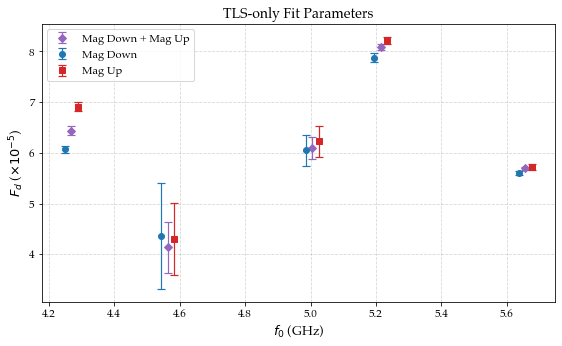

In [23]:
#Cooldown 11 - F4 and E1

import matplotlib.pyplot as plt
import numpy as np

# Data: f0 (GHz), Fd, Fd_err for each dataset
data = {
    "Mag Down + Mag Up": {
        "f0": [4.2696e9, 4.5639e9, 5.0048e9, 5.2147e9, 5.6559e9],
        "Fd": [6.4369e-5, 4.1365e-5, 6.0894e-5, 8.0856e-5, 5.6938e-5],
        "Fd_err": [8.3321e-7, 5.0277e-6, 2.1558e-6, 6.0807e-7, 3.1651e-7],
    },
    "Mag Down": {
        "f0": [4.2696e9, 4.5639e9, 5.0048e9, 5.2147e9, 5.6559e9],
        "Fd": [6.0659e-5, 4.3598e-5, 6.0478e-5, 7.8726e-5, 5.6026e-5],
        "Fd_err": [7.0175e-7, 1.0519e-5, 3.0347e-6, 8.9245e-7, 4.4422e-7],
    },
    "Mag Up": {
        "f0": [4.2696e9, 4.5639e9, 5.0048e9, 5.2147e9, 5.6559e9],
        "Fd": [6.9092e-5, 4.2985e-5, 6.2296e-5, 8.2246e-5, 5.7204e-5],
        "Fd_err": [9.0062e-7, 7.1606e-6, 3.0262e-6, 7.0686e-7, 5.8076e-7],
    },
}

colors = {"Mag Down + Mag Up": "tab:purple", "Mag Down": "tab:blue", "Mag Up": "tab:red"}
markers = {"Mag Down + Mag Up": "D", "Mag Down": "o", "Mag Up": "s"}
offsets = {"Mag Down + Mag Up": 0, "Mag Down": -0.02e9, "Mag Up": 0.02e9}  # small x-offset to avoid overlap

fig, ax = plt.subplots(figsize=(8, 5))

for label, d in data.items():
    f0 = np.array(d["f0"]) + offsets[label]
    Fd = np.array(d["Fd"])
    Fd_err = np.array(d["Fd_err"])

    ax.errorbar(
        f0 / 1e9,  # convert to GHz
        Fd * 1e5,  # scale for readability (units: 1e-5)
        yerr=Fd_err * 1e5,
        fmt=markers[label],
        color=colors[label],
        label=label,
        capsize=4,
        capthick=1.2,
        elinewidth=1.2,
        markersize=6,
        linewidth=0,
    )

ax.set_xlabel("$f_0$ (GHz)", fontsize=13)
ax.set_ylabel("$F_d$ ($\\times 10^{-5}$)", fontsize=13)
ax.set_title("TLS-only Fit Parameters", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig("tls_fit_params.png", dpi=150)
plt.show()

### 2f) Error analysis

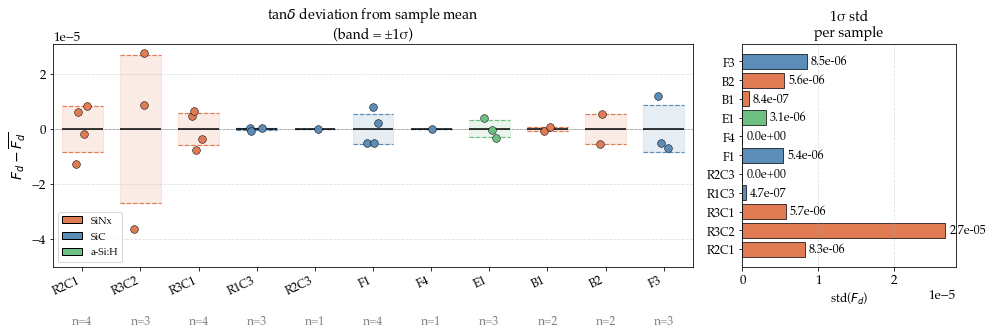

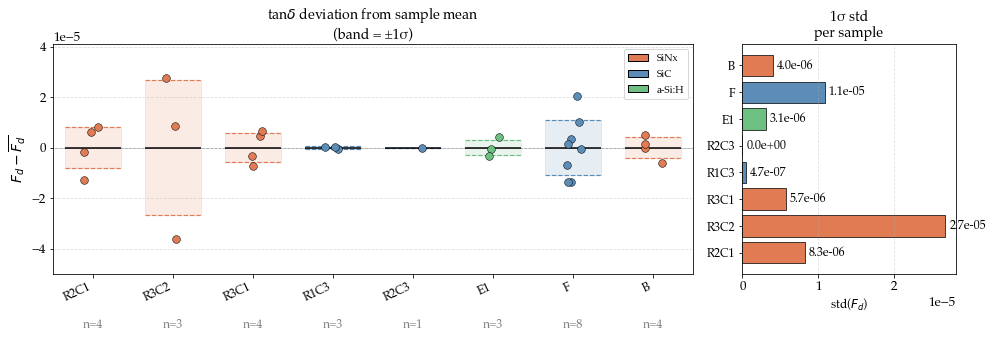

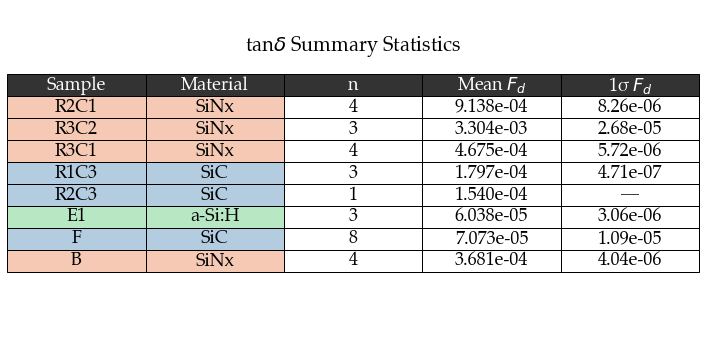

In [148]:
# figuring out the scatter relative to the mean in f0 and tand

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── All samples with their Fd values ──────────────────────────────────────────
samples = {
    'R2C1': {'freq': R2C1['freq'].values, 'Fd': R2C1['Fd'].values},
    'R3C2': {'freq': R3C2['freq'].values, 'Fd': R3C2['Fd'].values},
    'R3C1': {'freq': R3C1['freq'].values, 'Fd': R3C1['Fd'].values},
    'R1C3': {'freq': R1C3['freq'].values, 'Fd': R1C3['Fd'].values},
    'R2C3': {'freq': R2C3['freq'].values, 'Fd': R2C3['Fd'].values},
    'F1':   {'freq': F1['freq'].values,   'Fd': F1['Fd'].values},
    'F4':   {'freq': F4['freq'].values,   'Fd': F4['Fd'].values},
    'E1':   {'freq': E1['freq'].values,   'Fd': E1['Fd'].values},
    'B1':   {'freq': B1['freq'].values,   'Fd': B1['Fd'].values},
    'B2':   {'freq': B2['freq'].values,   'Fd': B2['Fd'].values},
    'F3':   {'freq': F3['freq'].values,   'Fd': F3['Fd'].values},
}

# ── Compute per-sample stats ───────────────────────────────────────────────────
stats = {}
for name, d in samples.items():
    Fd = d['Fd']
    stats[name] = {
        'mean':    np.mean(Fd),
        'median':  np.median(Fd),
        'std':     np.std(Fd),
        'min':     np.min(Fd),
        'max':     np.max(Fd),
        'n':       len(Fd),
        'freq_mean': np.mean(d['freq']),
    }

# ── Material type color mapping ───────────────────────────────────────────────
material_colors = {
    'R2C1':  ('SiNx',   '#E07B54'),
    'R3C2': ('SiNx',   '#E07B54'),
    'R3C1': ('SiNx',   '#E07B54'),
    'R1C3':    ('SiC',    '#5B8DB8'),
    'R2C3':     ('SiC',    '#5B8DB8'),
    'F1':              ('SiC',    '#5B8DB8'),
    'F4':          ('SiC',    '#5B8DB8'),
    'E1':           ('a-Si:H', '#6DBF82'),
    'B1':     ('SiNx',   '#E07B54'),
    'B2':     ('SiNx',   '#E07B54'),
    'F3':          ('SiC',    '#5B8DB8'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [3, 1]})
ax = axes[0]
ax_std = axes[1]

sample_names = list(samples.keys())
std_vals = []

# Legend handles
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='#E07B54', edgecolor='k', label='SiNx'),
    Patch(facecolor='#5B8DB8', edgecolor='k', label='SiC'),
    Patch(facecolor='#6DBF82', edgecolor='k', label='a-Si:H'),
]

for xi, name in enumerate(sample_names):
    Fd     = samples[name]['Fd']
    mean   = np.mean(Fd)
    std    = np.std(Fd)
    n      = len(Fd)
    color  = material_colors[name][1]
    std_vals.append(std)

    dev = Fd - mean

    # ±1σ shaded band
    ax.fill_between([xi - 0.35, xi + 0.35],
                    -std, std,
                    color=color, alpha=0.15, zorder=1)

    # ±1σ dashed lines
    ax.hlines([-std, std], xi - 0.35, xi + 0.35,
              colors=color, linestyles='--', linewidth=1.2, zorder=2)
    
    # Mean line
    ax.hlines(0, xi - 0.35, xi + 0.35,
              colors='black', linewidth=1.5, zorder=3)

    # Individual points
    jitter = (np.random.rand(n) - 0.5) * 0.25
    ax.scatter(xi + jitter, dev,
               s=60, zorder=4, color=color,
               edgecolors='k', linewidths=0.5)
    
    # Annotate n
    #ax.text(xi, -0.2, f'n={n}', ha='center', va='top', fontsize=14, color='gray')

ymin, ymax = ax.get_ylim()
ytext = ymin - 0.4 * (ymax - ymin)

for xi, name in enumerate(sample_names):
    n = len(samples[name]['Fd'])   # or samples_combined
    ax.text(
        xi, ytext,
        f'n={n}',
        ha='center',
        va='top',
        fontsize=12,
        color='gray'
    )

ax.set_ylim(-5e-5, ymax)

ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax.set_xticks(range(len(sample_names)))
ax.set_xticklabels([n.replace('\n', ' ') for n in sample_names],
                   fontsize=12, rotation=25, ha='right')
ax.set_ylabel(r'$F_d - \overline{F_d}$', fontsize=14)
ax.set_title('tan$\\delta$ deviation from sample mean\n(band = ±1σ)', fontsize=14)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
ax.set_xlim(-0.5, len(sample_names) - 0.5)
ax.legend(handles=legend_handles, fontsize=10, loc='lower left')

# ── Right panel: std per sample ───────────────────────────────────────────────
bar_colors = [material_colors[n][1] if stats[n]['n'] > 1 else 'lightgray'
              for n in sample_names]
bars = ax_std.barh(range(len(sample_names)), std_vals,
                   color=bar_colors, edgecolor='k', linewidth=0.7)
ax_std.set_yticks(range(len(sample_names)))
ax_std.set_yticklabels([n.replace('\n', ' ') for n in sample_names], fontsize=12)
ax_std.set_xlabel('std($F_d$)', fontsize=12)
ax_std.set_title('1σ std\nper sample', fontsize=14)
ax_std.grid(True, axis='x', linestyle='--', alpha=0.4)

for bar, v, n in zip(bars, std_vals, sample_names):
    ax_std.text(bar.get_width() + max(std_vals)*0.02,
                bar.get_y() + bar.get_height()/2,
                f'{v:.1e}', va='center', fontsize=12)

plt.tight_layout()
plt.show()



# ── Combine F1/F3/F4 → F and B1/B2 → B ──────────────────────────────────────
F_combined = pd.DataFrame({
    'freq': np.concatenate([F1['freq'].values, F3['freq'].values, F4['freq'].values]),
    'Fd':   np.concatenate([F1['Fd'].values,   F3['Fd'].values,   F4['Fd'].values]),
})

B_combined = pd.DataFrame({
    'freq': np.concatenate([B1['freq'].values, B2['freq'].values]),
    'Fd':   np.concatenate([B1['Fd'].values,   B2['Fd'].values]),
})

samples_combined = {
    'R2C1':  {'freq': R2C1['freq'].values, 'Fd': R2C1['Fd'].values},
    'R3C2': {'freq': R3C2['freq'].values, 'Fd': R3C2['Fd'].values},
    'R3C1': {'freq': R3C1['freq'].values, 'Fd': R3C1['Fd'].values},
    'R1C3':    {'freq': R1C3['freq'].values, 'Fd': R1C3['Fd'].values},
    'R2C3':     {'freq': R2C3['freq'].values, 'Fd': R2C3['Fd'].values},
    'E1':           {'freq': E1['freq'].values,   'Fd': E1['Fd'].values},
    'F':               {'freq': F_combined['freq'].values, 'Fd': F_combined['Fd'].values},
    'B':      {'freq': B_combined['freq'].values, 'Fd': B_combined['Fd'].values},
}

material_colors_combined = {
    'R2C1':  ('#E07B54'),
    'R3C2': ('#E07B54'),
    'R3C1': ('#E07B54'),
    'R1C3':    ('#5B8DB8'),
    'R2C3':     ('#5B8DB8'),
    'E1':           ('#6DBF82'),
    'F':               ('#5B8DB8'),
    'B':      ('#E07B54'),
}

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [3, 1]})
ax = axes[0]
ax_std = axes[1]

sample_names = list(samples_combined.keys())
std_vals = []

legend_handles = [
    Patch(facecolor='#E07B54', edgecolor='k', label='SiNx'),
    Patch(facecolor='#5B8DB8', edgecolor='k', label='SiC'),
    Patch(facecolor='#6DBF82', edgecolor='k', label='a-Si:H'),
]

for xi, name in enumerate(sample_names):
    Fd    = samples_combined[name]['Fd']
    mean  = np.mean(Fd)
    std   = np.std(Fd)
    n     = len(Fd)
    color = material_colors_combined[name]
    std_vals.append(std)

    dev = Fd - mean

    ax.fill_between([xi - 0.35, xi + 0.35],
                    -std, std,
                    color=color, alpha=0.15, zorder=1)
    ax.hlines([-std, std], xi - 0.35, xi + 0.35,
              colors=color, linestyles='--', linewidth=1.2, zorder=2)
    ax.hlines(0, xi - 0.35, xi + 0.35,
              colors='black', linewidth=1.5, zorder=3)

    jitter = (np.random.rand(n) - 0.5) * 0.25
    ax.scatter(xi + jitter, dev,
               s=60, zorder=4, color=color,
               edgecolors='k', linewidths=0.5)

    #ax.text(xi, -0.28, f'n={n}', ha='center', va='top', fontsize=14, color='gray')

ymin, ymax = ax.get_ylim()
ytext = ymin - 0.4 * (ymax - ymin)

for xi, name in enumerate(sample_names):
    n = len(samples_combined[name]['Fd'])   # or samples_combined
    ax.text(
        xi, ytext,
        f'n={n}',
        ha='center',
        va='top',
        fontsize=12,
        color='gray'
    )

ax.set_ylim(-5e-5, ymax+1e-5)

ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax.set_xticks(range(len(sample_names)))
ax.set_xticklabels([n.replace('\n', ' ') for n in sample_names],
                   fontsize=12, rotation=25, ha='right')
ax.set_ylabel(r'$F_d - \overline{F_d}$', fontsize=14)
ax.set_title('tan$\\delta$ deviation from sample mean\n(band = ±1σ)', fontsize=14)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
ax.set_xlim(-0.5, len(sample_names) - 0.5)
ax.legend(handles=legend_handles, fontsize=10, loc='upper right')

# ── Right panel ───────────────────────────────────────────────────────────────
bar_colors = [material_colors_combined[n] if len(samples_combined[n]['Fd']) > 1
              else 'lightgray' for n in sample_names]
bars = ax_std.barh(range(len(sample_names)), std_vals,
                   color=bar_colors, edgecolor='k', linewidth=0.7)
ax_std.set_yticks(range(len(sample_names)))
ax_std.set_yticklabels([n.replace('\n', ' ') for n in sample_names], fontsize=12)
ax_std.set_xlabel('std($F_d$)', fontsize=12)
ax_std.set_title('1σ std\nper sample', fontsize=14)
ax_std.grid(True, axis='x', linestyle='--', alpha=0.4)

for bar, v in zip(bars, std_vals):
    ax_std.text(bar.get_width() + max(std_vals)*0.02,
                bar.get_y() + bar.get_height()/2,
                f'{v:.1e}', va='center', fontsize=12)

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
summary_data = []
for name in sample_names:
    Fd   = samples_combined[name]['Fd']
    mean = np.mean(Fd)
    std  = np.std(Fd)
    n    = len(Fd)
    mat  = 'SiNx' if material_colors_combined[name] == '#E07B54' else \
           'SiC'  if material_colors_combined[name] == '#5B8DB8' else 'a-Si:H'
    summary_data.append({
        'Sample':    name.replace('\n', ' '),
        'Material':  mat,
        'n':         n,
        'Mean Fd':   mean,
        'σ(Fd)':     std,
    })

df_summary = pd.DataFrame(summary_data)

# ── Display as formatted table ────────────────────────────────────────────────
fig, ax_tab = plt.subplots(figsize=(10, 5))
ax_tab.axis('off')

col_labels = ['Sample', 'Material', 'n', 'Mean $F_d$', '1σ $F_d$']
cell_text  = []
cell_colors = []

mat_color_map = {'SiNx': '#F5C9B3', 'SiC': '#B3CCE0', 'a-Si:H': '#B8E8C3'}

for _, row in df_summary.iterrows():
    cell_text.append([
        row['Sample'],
        row['Material'],
        str(int(row['n'])),
        f"{row['Mean Fd']:.3e}",
        f"{row['σ(Fd)']:.2e}" if row['n'] > 1 else '—',
    ])
    c = mat_color_map[row['Material']]
    cell_colors.append([c, c, 'white', 'white', 'white'])

table = ax_tab.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellColours=cell_colors,
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(18)
table.scale(1, 1.5)

# Bold header
for j in range(len(col_labels)):
    table[(0, j)].set_facecolor('#333333')
    table[(0, j)].get_text().set_color('white')
    table[(0, j)].get_text().set_fontweight('bold')

plt.title('tan$\\delta$ Summary Statistics', fontsize=20, y=0.85)
plt.tight_layout()
plt.show()

## 3) Our data in the context of the field

### 3a) tand vs T

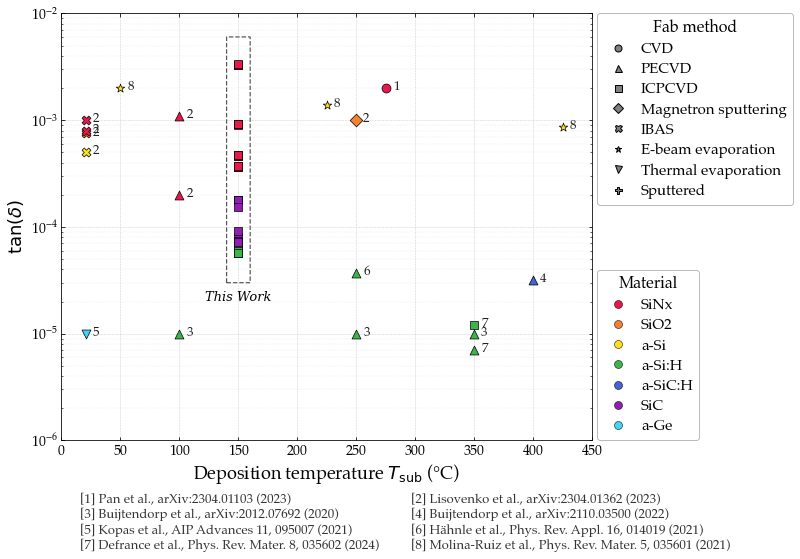

In [155]:
#tan(delta) vs. T 

#Note: I couldn't find any **microwave** measurements for SuperSpec and u-spec

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patheffects as pe


#Pan et al. 2023
Pan = pd.DataFrame({
    "freq": [1.8605],
    "tand": [2.0e-3],
    "fab": "CVD",
    "T_sub": [275],
    "material": ["SiNx"],
    "author": ["Pan et al. 2023"]
})

#Lisovenko et al. 2023 - SPT-SLIM
Lisovenko = pd.DataFrame({
    "freq": [7.62, 5, 5, 5, 5, 5, 5], #cited 5-10 GHz
    "tand": [1e-3, 7.5e-4, 5e-4, 8e-4, 1e-3, 2e-4, 1.1e-3], #second point is actually 8e-4 but then it isn't shown cuz it is under the 4th point
    "fab": ["MS", "IBAS", "IBAS", "IBAS", "IBAS", "PECVD", "PECVD"],
    "T_sub": [250, 21, 21, 21, 21, 100, 100],
    "material": ["SiO2", "SiO2", "a-Si", "SiNx", "SiNx", "SiNx", "SiNx"],
    "author": ["Lisovenko et al. 2023"] * 7
})

#all of these tand are upper bounds, didn't saturate TLS, should we include? - 2012.07692
Buijtendorp2020 = pd.DataFrame({
    "freq": [5, 5, 5], #cited 5-10 GHz
    "tand": [1e-5, 1e-5, 1e-5],
    "fab": ["PECVD", "PECVD", "PECVD"],
    "T_sub": [100, 250, 350],
    "material": ["a-Si:H", "a-Si:H", "a-Si:H"], 
    "author": ["Buijtendorp et al. 2020"] * 3
})

#O'Connell didn't publish T_sub or fab processes
OConnell = pd.DataFrame({
    "freq": [6, 6, 6, 6, 6, 6], #cited 5-10 GHz
    "tand": [2.5e-5, 7e-5, 1e-4, 3.1e-4, 2.8e-3, 5.5e-4],
    "fab": ["N/A", "N/A", "N/A", "Thermal Evaporation", "PECVD", "Sputtered"],
    "T_sub": [None, None, None, None, None, None],
    "material": ["a-Si:H","a-Si:H", "SiNx", "SiO2", "SiO2", "SiO2"], 
    "author": ["O'Connell et al. 2008"] * 6
})


#2110.03500 - DESHIMA 2
Buijtendorp2022 = pd.DataFrame({
    "freq": [7.0],
    "tand": [3.2e-5],
    "fab": ["PECVD"],
    "T_sub": [400],
    "material": ["a-SiC:H"], 
    "author": ["Buijtendorp et al. 2022"]
})

Kopas = pd.DataFrame({
    "freq": [7],
    "tand": [1e-5],
    "fab": ["Thermal Evaporation"], #type of PVD
    "T_sub": [21], #someone should check this
    "material": ["a-Ge"], 
    "author": ["Kopas et al. 2021"]
})

#Buijtendorp a-Si:H, Hahnle et al. 2021
Hahnle = pd.DataFrame({
    "freq": [6],
    "tand": [3.7e-5],
    "fab": ["PECVD"],
    "T_sub": [250], #this is stated in section 3.1 of BTB's thesis
    "material": ["a-Si:H"], 
    "author": ["Hähnle et al. 2021"]
})

#Defrance et al. 2024
Defrance = pd.DataFrame({
    "freq": [1, 1],
    "tand": [7e-6, 1.2e-5],
    "fab": ["PECVD", "ICPCVD"],
    "T_sub": [350, 350], 
    "material": ["a-Si:H", "a-Si:H"], 
    "author": ["Defrance et al. 2024"] * 2
})

#Gao et al. 2009 - doesn't include T_sub
Gao = pd.DataFrame({
    "freq": [5],
    "tand": [6e-4],
    "fab": ["Sputtered"],
    "T_sub": [None], 
    "material": ["SiO2"], 
    "author": ["Gao et al. 2009"]
})

Molina_Ruiz = pd.DataFrame({
    "freq": [5, 5, 5],
    "tand": [2e-3, 1.4e-3, 8.6e-4],
    "fab": ["E-beam", "E-beam", "E-beam"],
    "T_sub": [50, 225, 425], 
    "material": ["a-Si", "a-Si", "a-Si"], 
    "author": ["Molina-Ruiz et al. 2021"] * 3
})

LANCE = pd.DataFrame({
    "freq": [5.42,5.75,6.13,6.56, #R2C1 
             5.56, 6.305, 6.755, #R3C2
             5.19, 5.50, 5.87, 6.28, #R3C1
             4.66, 4.94, 5.2790, #R1C3
             5.83, #R2C3
             5.00, 5.31, 5.66, 6.06, #F1
             5.2147, #F4
             4.2696, 5.0048, 5.6559, #E1
             5.4504, 5.7958, #B1 
             5.4597, 5.46, #B2
             4.99, 5.28, 5.65], #F3
    "tand": [9.01e-4,9.12e-4,9.2e-4,9.22e-4,
             33.13e-4, 32.68e-4, 33.32e-4,
             4.60e-4, 4.64E-04, 4.72E-04, 4.74E-04,
             1.80e-4, 1.79e-4, 1.80e-4,
             1.54e-4,
             0.70e-4, 0.64e-4, 0.57e-4, 0.57e-4,
             8.0856e-05,
             6.4369e-5, 5.9822e-05, 5.6938e-05,
             3.6796e-04, 3.6965e-04,
             3.6187e-04, 3.73e-04,
             0.74e-04, 0.91e-04, 0.72e-04],
    "fab": ["ICPCVD", "ICPCVD", "ICPCVD", "ICPCVD",
            "ICPCVD", "ICPCVD", "ICPCVD",
            "ICPCVD", "ICPCVD", "ICPCVD", "ICPCVD", 
            "ICPCVD", "ICPCVD", "ICPCVD",
            "ICPCVD",
            "ICPCVD", "ICPCVD", "ICPCVD", "ICPCVD",
            "ICPCVD",
            "ICPCVD", "ICPCVD", "ICPCVD",
            "ICPCVD", "ICPCVD",
            "ICPCVD", "ICPCVD",
            "ICPCVD", "ICPCVD","ICPCVD"],
    "T_sub": [150, 150, 150, 150,
              150, 150, 150,
              150, 150, 150, 150,
              150, 150, 150,
              150,
              150, 150, 150, 150,
              150,
              150, 150, 150,
              150, 150,
              150, 150,
              150, 150, 150],
    "material": ["SiNx", "SiNx", "SiNx", "SiNx",
                 "SiNx", "SiNx", "SiNx",
                 "SiNx", "SiNx", "SiNx", "SiNx",
                 "SiC", "SiC", "SiC",
                 "SiC",
                 "SiC", "SiC", "SiC", "SiC",
                 "SiC",
                 "a-Si:H", "a-Si:H", "a-Si:H",
                 "SiNx", "SiNx",
                 "SiNx", "SiNx",
                 "SiC", "SiC", "SiC"],
    "author": ["LANCE"] * 30
})
 
    
"""
BTB Fig 5.2:
1 - Buijtendorp2022 data point
2 - BTB paper mm-wave, not relevant 
3 - one a-Si:H point from S. Hähnle, K. Kouwenhoven, B. Buijtendorp, A. Endo, K. Karatsu, D. Thoen, V. Murugesan, and J. Baselmans, “Superconducting Microstrip Losses at Microwave and Submillimeter Wavelengths,” Phys. Rev. Appl., vol. 16, no. 1, p. 014019, 2021.
4 - 2 a-Si:H points from F. Defrance, A. D. Beyer, S. Shu, J. Sayers, and S. R. Golwala, “Characterization of the low electric field and zero-temperature two-level-system loss in hydrogenated amorphous silicon,” Physical Review Materials, vol. 8, p. 035602, Mar. 2024.
5 - O'Connell, LC a-Si:H
6 - O'Connell, CPW a-Si:H
7 - doesn't match O'Connell table, ignoring it
8 - Kopas, a-Ge from C. J. Kopas, J. Gonzales, S. Zhang, D. R. Queen, B. Wagner, M. Robinson, J. Huffman, and N. Newman, “Low microwave loss in deposited Si and Ge thin-film dielectrics at single-photon power and low temperatures,” AIP Advances, vol. 11, p. 095007, Sept. 2021.
9 - O'Connell, SiNx
10 - SuperSpec, mm-wave not relavent 
11 - Endo, mm-wave not relavent
12 - O'Connell, Thermal SiO2
13 - O'Connell, PECVD SiO2
14 - Gao one SiO2 point at microwave
15 - O'Connell, sputtered a-Si
* 16 - one a-Si point from M. Molina-Ruiz, Y. J. Rosen, H. C. Jacks, M. R. Abernathy, T. H. Metcalf, X. Liu, J. L. DuBois, and F. Hellman, “Origin of mechanical and dielectric losses from two-level systems in amorphous silicon,” Phys. Rev. Mater., vol. 5, no. 3, p. 035601, 2021.
* 17 - one a-Si point from same paper ^
* 18 - one a-Si point from same paper ^
""";

# ── Reference numbering ───────────────────────────────────────────────────────
# Assign a number to each unique non-LANCE author
# LANCE = "This Work", no number
ref_authors = [
    "Pan et al. 2023",
    "Lisovenko et al. 2023",
    "Buijtendorp et al. 2020",
    "Buijtendorp et al. 2022",
    "Kopas et al. 2021",
    "Hähnle et al. 2021",
    "Defrance et al. 2024",
    "Molina-Ruiz et al. 2021",
]
author_to_ref = {a: i+1 for i, a in enumerate(ref_authors)}

ref_strings = {
    "Pan et al. 2023":           "Pan et al., arXiv:2304.01103 (2023)",
    "Lisovenko et al. 2023":     "Lisovenko et al., arXiv:2304.01362 (2023)",
    "Buijtendorp et al. 2020":   "Buijtendorp et al., arXiv:2012.07692 (2020)",
    "Buijtendorp et al. 2022":   "Buijtendorp et al., arXiv:2110.03500 (2022)",
    "Kopas et al. 2021":         "Kopas et al., AIP Advances 11, 095007 (2021)",
    "Hähnle et al. 2021":        "Hähnle et al., Phys. Rev. Appl. 16, 014019 (2021)",
    "Defrance et al. 2024":      "Defrance et al., Phys. Rev. Mater. 8, 035602 (2024)",
    "Molina-Ruiz et al. 2021":   "Molina-Ruiz et al., Phys. Rev. Mater. 5, 035601 (2021)",
}

# ── Combine, drop rows with no T_sub ──────────────────────────────────────────
df = pd.concat([Pan, Lisovenko, Buijtendorp2020, OConnell, Buijtendorp2022,
                Kopas, Hahnle, Defrance, Gao, Molina_Ruiz, LANCE],
               ignore_index=True)
df = df.dropna(subset=["T_sub"]).reset_index(drop=True)

# ── Visual encodings ──────────────────────────────────────────────────────────
material_colors = {
    "SiNx":    "#e6194b",
    "SiO2":    "#f58231",
    "a-Si":    "#ffe119",
    "a-Si:H":  "#3cb44b",
    "a-SiC:H": "#4363d8",
    "SiC":     "#911eb4",
    "a-Ge":    "#42d4f4",
}

fab_markers = {
    "CVD":                 "o",
    "PECVD":               "^",
    "ICPCVD":              "s",
    "MS":                  "D",
    "IBAS":                "X",
    "Sputtered":           "P",
    "Thermal Evaporation": "v",
    "E-beam":              "*",
    "N/A":                 "+",
}

# Marker sizes per shape — squares and diamonds get boosted
fab_sizes = {
    "CVD":                 80,
    "PECVD":               80,
    "ICPCVD":              80,   
    "MS":                  80,   # diamond
    "IBAS":                80,
    "Sputtered":           80,
    "Thermal Evaporation": 80,
    "E-beam":              80,   # star already big but needs size too
    "N/A":                 80,   # plus
}

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))   # wider for legend breathing room
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Palatino"] 
plt.rcParams["font.size"] = 13          # base size for everything

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for _, row in df.iterrows():
    color  = material_colors.get(row["material"], "#888888")
    marker = fab_markers.get(row["fab"], "o")
    sz     = fab_sizes.get(row["fab"], 80)
    ax.scatter(row["T_sub"], row["tand"],
               color=color, marker=marker,
               s=sz, linewidths=0.7, edgecolors="k",
               zorder=4, clip_on=False)

# ── Reference number annotations ─────────────────────────────────────────────
# For each author group, place the number near the centroid of their points
# offset slightly up-right so it doesn't overlap the marker
for _, row in df.iterrows():
    author = row["author"]
    if author == "LANCE" or author not in author_to_ref:
        continue
    ax.annotate(str(author_to_ref[author]),
                xy=(row["T_sub"], row["tand"]),
                xytext=(7, -2), textcoords="offset points",
                fontsize=13, color="#222222", fontweight="bold", zorder=6)
    
# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_yscale("log")
ax.set_xlim(0, 450)        # small pad on left so ~20°C points aren't clipped
ax.set_ylim(1e-6, 1e-2)

# Grid
ax.grid(True, which="major", linestyle="--", linewidth=0.5, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":",  linewidth=0.4, color="#d8d8d8", zorder=0)  # slightly more visible
ax.set_axisbelow(True)

# Labels
FSIZE = 18      # axis labels
ax.set_xlabel("Deposition temperature $T_{\\rm sub}$ (°C)", fontsize=FSIZE)
ax.set_ylabel("$\\tan(\\delta)$", fontsize=FSIZE)
ax.tick_params(axis="both", which="both", direction="in", top=True, right=True,
               labelsize=14)

# Minor y-axis tick labels at half-decades
import matplotlib.ticker as ticker
ax.yaxis.set_minor_formatter(ticker.LogFormatterSciNotation(minor_thresholds=(2, 0.5)))

# ── "This Work" box ───────────────────────────────────────────────────────────
from matplotlib.patches import FancyBboxPatch

rect = FancyBboxPatch((140, 3e-5), 20, 6e-3 - 1e-5,
                       boxstyle="round,pad=0",
                       facecolor="none", edgecolor="#555555",
                       linewidth=1.2, linestyle="--", zorder=5)
ax.add_patch(rect)

ax.annotate("This Work", xy=(150, 3e-5),
            xytext=(0, -18), textcoords="offset points",
            fontsize=13, ha="center",
            fontfamily="DejaVu Serif",   # more professional serif font
            fontstyle="italic")

# ── Legends ───────────────────────────────────────────────────────────────────
LFSIZE = 15     # legend entries
LTFSIZE = 16    # legend titles

fab_legend_entries = [
    ("CVD",                "CVD"),
    ("PECVD",              "PECVD"),
    ("ICPCVD",             "ICPCVD"),
    ("MS",                 "Magnetron sputtering"),
    ("IBAS",               "IBAS"),
    ("E-beam",             "E-beam evaporation"),
    ("Thermal Evaporation","Thermal evaporation"),
    ("Sputtered",          "Sputtered"),
]
fab_handles = [
    mlines.Line2D([], [], color="k", marker=fab_markers[k], linestyle="None",
                  markersize=7, markerfacecolor="grey", label=lbl)
    for k, lbl in fab_legend_entries
]
leg1 = ax.legend(handles=fab_handles, title="Fab method",
                 fontsize=LFSIZE, title_fontsize=LTFSIZE,
                 loc="upper left", bbox_to_anchor=(1.01, 1.0),
                 borderaxespad=0, frameon=True, edgecolor="#aaaaaa",
                 handletextpad=0.5, labelspacing=0.35)
ax.add_artist(leg1)

mat_handles = [
    mlines.Line2D([], [], color=c, marker="o", linestyle="None",
                  markersize=8, markeredgecolor="k", markeredgewidth=0.5,
                  label=m)
    for m, c in material_colors.items()
]
ax.legend(handles=mat_handles, title="Material",
          fontsize=LFSIZE, title_fontsize=LTFSIZE,
          loc="lower left", bbox_to_anchor=(1.01, 0.0),
          borderaxespad=0, frameon=True, edgecolor="#aaaaaa",
          handletextpad=0.5, labelspacing=0.35)

# ── Reference box at bottom of figure ────────────────────────────────────────
ref_lines = [f"[{author_to_ref[a]}] {ref_strings[a]}" for a in ref_authors]
left_text  = "\n".join([ref_lines[i]   for i in range(0, len(ref_lines), 2)])
right_text = "\n".join([ref_lines[i+1] for i in range(0, len(ref_lines), 2)])

fig.text(0.12, 0.03, left_text,  fontsize=13, family="serif",
         va="bottom", ha="left", color="#333333")
fig.text(0.58, 0.03, right_text, fontsize=13, family="serif",
         va="bottom", ha="left", color="#333333")

plt.tight_layout(rect=[0, 0.12, 1, 1])   # bump up bottom margin too
plt.savefig("plots/tand_vs_Tsub.png", dpi=150, bbox_inches="tight")
plt.show()

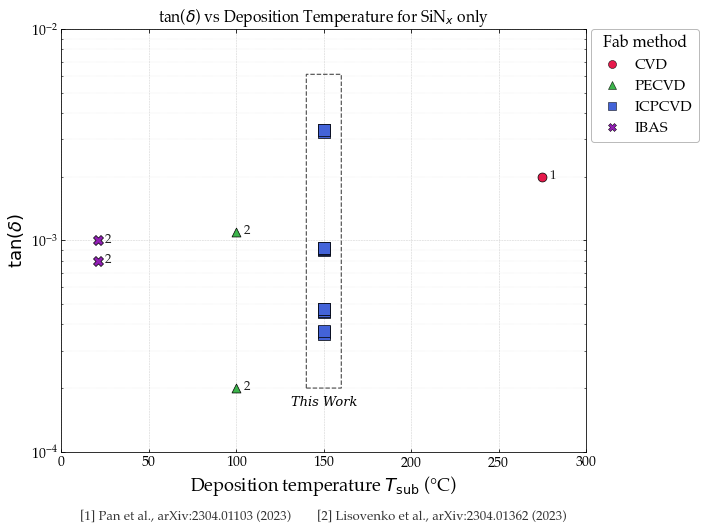

In [157]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.ticker as ticker
from matplotlib.patches import FancyBboxPatch

# ── Filter ────────────────────────────────────────────────────────────────────
df_sinx = df[df["material"] == "SiNx"].reset_index(drop=True)

# ── Visual encodings ──────────────────────────────────────────────────────────
fab_colors = {
    "CVD":       "#e6194b",
    "PECVD":     "#3cb44b",
    "ICPCVD":    "#4363d8",
    "IBAS":      "#911eb4",
}

fab_markers = {
    "CVD":       "o",
    "PECVD":     "^",
    "ICPCVD":    "s",
    "IBAS":      "X",
}

fab_sizes = {
    "CVD":    80,
    "PECVD":  80,
    "ICPCVD": 130,
    "IBAS":   100,
}

# ── Figure ────────────────────────────────────────────────────────────────────
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"]  = ["Palatino"]
plt.rcParams["font.size"]   = 13

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ── Scatter ───────────────────────────────────────────────────────────────────
for _, row in df_sinx.iterrows():
    color  = fab_colors.get(row["fab"], "#888888")
    marker = fab_markers.get(row["fab"], "o")
    sz     = fab_sizes.get(row["fab"], 80)
    ax.scatter(row["T_sub"], row["tand"],
               color=color, marker=marker,
               s=sz, linewidths=0.7, edgecolors="k",
               zorder=4, clip_on=False)

# ── Reference number annotations ─────────────────────────────────────────────
for _, row in df_sinx.iterrows():
    author = row["author"]
    if author == "LANCE" or author not in author_to_ref:
        continue
    ax.annotate(str(author_to_ref[author]),
                xy=(row["T_sub"], row["tand"]),
                xytext=(7, -2), textcoords="offset points",
                fontsize=13, color="#222222", fontweight="bold", zorder=6)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_yscale("log")
ax.set_xlim(0, 300)
ax.set_ylim(1e-4, 1e-2)

ax.grid(True, which="major", linestyle="--", linewidth=0.5, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":",  linewidth=0.4, color="#d8d8d8", zorder=0)
ax.set_axisbelow(True)

FSIZE = 18
ax.set_xlabel("Deposition temperature $T_{\\rm sub}$ (°C)", fontsize=FSIZE)
ax.set_ylabel("$\\tan(\\delta)$", fontsize=FSIZE)
ax.tick_params(axis="both", which="both", direction="in", top=True, right=True,
               labelsize=14)

# ── "This Work" box ───────────────────────────────────────────────────────────
rect = FancyBboxPatch((140, 2e-4), 20, 6e-3 - 1e-4,
                       boxstyle="round,pad=0",
                       facecolor="none", edgecolor="#555555",
                       linewidth=1.2, linestyle="--", zorder=5)
ax.add_patch(rect)

ax.annotate("This Work", xy=(150, 2e-4),
            xytext=(0, -18), textcoords="offset points",
            fontsize=13, ha="center",
            fontfamily="DejaVu Serif",
            fontstyle="italic")

# ── Legend ────────────────────────────────────────────────────────────────────
LFSIZE  = 15
LTFSIZE = 16

fab_legend_entries = [
    ("CVD",    "CVD"),
    ("PECVD",  "PECVD"),
    ("ICPCVD", "ICPCVD"),
    ("IBAS",   "IBAS"),
]
fab_handles = [
    mlines.Line2D([], [], color=fab_colors[k], marker=fab_markers[k], linestyle="None",
                  markersize=8, markeredgecolor="k", markeredgewidth=0.5, label=lbl)
    for k, lbl in fab_legend_entries
]
ax.legend(handles=fab_handles, title="Fab method",
          fontsize=LFSIZE, title_fontsize=LTFSIZE,
          loc="upper left", bbox_to_anchor=(1.01, 1.0),
          borderaxespad=0, frameon=True, edgecolor="#aaaaaa",
          handletextpad=0.5, labelspacing=0.4)

# ── Reference box at bottom ───────────────────────────────────────────────────
# Only show refs that appear in the SiNx plot
sinx_authors = df_sinx["author"].unique()
sinx_ref_authors = [a for a in ref_authors if a in sinx_authors]

ref_lines_sinx = [f"[{author_to_ref[a]}] {ref_strings[a]}" for a in sinx_ref_authors]

# 2 per row
col_pairs = [ref_lines_sinx[i:i+2] for i in range(0, len(ref_lines_sinx), 2)]
left_text  = "\n".join([pair[0] for pair in col_pairs])
right_text = "\n".join([pair[1] if len(pair) > 1 else "" for pair in col_pairs])

fig.text(0.12, 0.08, left_text,  fontsize=13, family="serif",
         va="bottom", ha="left", color="#333333")
fig.text(0.45, 0.08, right_text, fontsize=13, family="serif",
         va="bottom", ha="left", color="#333333")

plt.title(r"tan($\delta$) vs Deposition Temperature for SiN$_x$ only")
plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.savefig("plots/tand_vs_Tsub_SiNx_only.png", dpi=150, bbox_inches="tight")
plt.show()